In [1]:
import os
os.getcwd()

'C:\\Users\\m_sri'

In [ ]:
#C:\MYPapers\Quantum          Anaconda Env: SGC

# QRC Lyapunov Companion Notebook--Extended (v2)

This notebook includes:
- Loren-96 simulation and Jacobian (chaotic benchmark)
- Largets and multi-exponent Lyapunov estimation (QR/Benettin)
- Covariant Lyapunov Vectors (CLVs) via Ginelli backward recursion
- **Forecasting pipeline** (ridge-regression readout) for one-step and multi-step rollouts
    
You can replace the ESN stand-in with your Quantum Reservoir ('.step(u_t)') implementation.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.set_printoptions(suppress=True, linewidth=140)

## Lorenz-96 dynamics and Jacobian

In [3]:
def lorenz96(x, F=8.0):
    K = x.size
    xp1 = np.roll(x, -1)
    xm1 = np.roll(x,1)
    xm2 = np.roll(x,2)
    return (xp1 - xm2) * xm1 -x + F

def rk4_step(f, x, dt, **kwargs):
    k1 = f(x, **kwargs)
    k2 = f(x + 0.5*dt*k1, **kwargs)
    k3 = f(x + 0.5*dt*k2, **kwargs)
    k4 = f(x + dt*k3, **kwargs)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def simulate_l96(K=20, F=8.0, dt=0.01, steps=3000, x0=None, burn=1000):
    x=F*np.ones(K) if x0 is None else x0.copy()
    x[0] += 0.01
    traj = []
    for t in range(steps + burn):
        x = rk4_step(lorenz96, x, dt, F=F)
        if t>= burn:
            traj.append(x.copy())
    return np.array(traj)

def jacobian_l96(x):
    K =x.size
    J=np.zeros((K, K))
    for i in range(K):
        im1 = (i -1) % K
        im2 = (i -2) % K
        ip1 = (i -1) % K
        J[i, i] = -1.0
        J[i, im1] = x[ip1] - x[im2]
        J[i, ip1] = x[im1]
        J[i, im2] = -x[im1]
    return J

traj = simulate_l96(K=20, F=8.0, dt=0.01, steps=2500)
traj.shape
    

(2500, 20)

### Largest Lyapunov exponent (finit-time, QR with Euler tangent  map)


Estimated largest LE:1.794430474806921


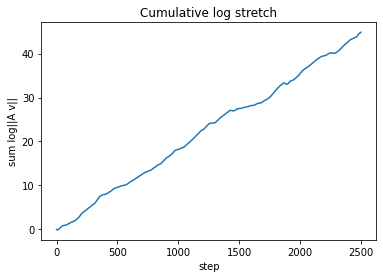

In [4]:
def largest_le_qr(traj, dt=0.01, stride=1):
    T, K = traj.shape
    v = np.random.randn(K)
    v /= np.linalg.norm(v)
    logs = []
    for t in range(0,T,stride):
        J = jacobian_l96(traj[t])
        A = np.eye(K) + dt*J
        v = A @ v
        ln = np.linalg.norm(v)
        v /= ln
        logs.append(np.log(ln))
    lam = np.sum(logs) / (len(logs) * dt * stride)
    return lam, np.array(logs)

lam1, logs1 = largest_le_qr(traj, dt=0.01, stride=1)
print(f"Estimated largest LE:{lam1}")
plt.figure(); plt.plot(np.cumsum(logs1)); plt.title('Cumulative log stretch');plt.xlabel('step');plt.ylabel('sum log||A v||');
plt.show()

## Multi-exponent QR for leading spectrum

Leading LEs:[1.85144643 1.53051824 1.28522942 0.89179213 0.556259  ]


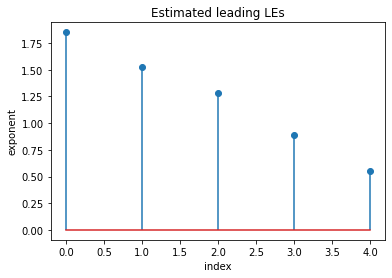

In [6]:
def multi_le_qr(traj, dt=0.01, q=5, stride=1):
    T, K = traj.shape
    Q, _ = np.linalg.qr(np.random.randn(K, q))
    Q_list = [Q.copy()]
    R_list = []
    sums = np.zeros(q)
    steps = 0
    for t in range(0,T,stride):
        J = jacobian_l96(traj[t])
        A = np.eye(K) + dt*J
        Y = A @ Q
        Q, R = np.linalg.qr(Y)
        R_list.append(R)
        Q_list.append(Q.copy())
        sums += np.log(np.abs(np.diag(R)))
        steps += 1
    lambdas = sums / (steps * dt * stride)
    return lambdas, Q_list, R_list

lams, Q_list, R_list = multi_le_qr(traj, dt=0.01, q=5, stride=1)
print(f"Leading LEs:{lams}")
plt.figure(); plt.stem(lams, use_line_collection=True); plt.title('Estimated leading LEs');plt.xlabel('index');
plt.ylabel('exponent');
plt.show()

## Covariant Lyapunov Vectors (CLVs) via backward recursion

In [7]:
def clv_backward(Q_list, R_list):
    T = len(R_list)
    q = R_list[0].shape[0]
    V_list = [None]*T
    W = np.eye(q)
    for t in range(T-1, -1, -1):
        Rtp1 = R_list[t]
        W = np.linalg.solve(Rtp1, W)
        V_t = Q_list[t] @ W
        V_list[t] = V_t
    return V_list

V_list = clv_backward(Q_list, R_list)
len(V_list), V_list[0].shape

        

(2500, (20, 5))

### CLV angle diagnostics (CLV1 vs CLV2)

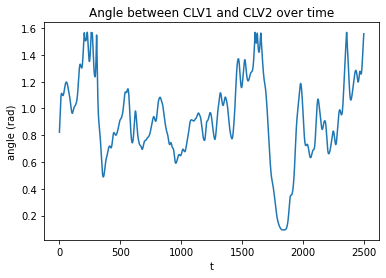

In [8]:
def vector_angle(u, v):
    un = u/np.linalg.norm(u)
    vn = v/np.linalg.norm(v)
    c = np.clip(np.abs(un @ vn), 0.0, 1.0)
    return np.arccos(c)

angles = []
for V in V_list:
    v1, v2 = V[:,0], V[:,1]
    angles.append(vector_angle(v1, v2))
angles = np.array(angles)
plt.figure();
plt.plot(angles);
plt.title('Angle between CLV1 and CLV2 over time')
plt.xlabel('t')
plt.ylabel('angle (rad)')
plt.show()

# Forecasting with Readout Training (Ridge Regression)

This section adds a standard reservoir computing readout pipeline for **one-step** and **multi-step** time series forecasting. 
It uses a simple ESN stand-in (helps to run immediately); Note: you can swap in your QRC with a `.step(u_t)`.

Chosen ridge λ = 1.0e-02, Val NRMSE = 0.0612
Test NRMSE (one-step): 0.0352


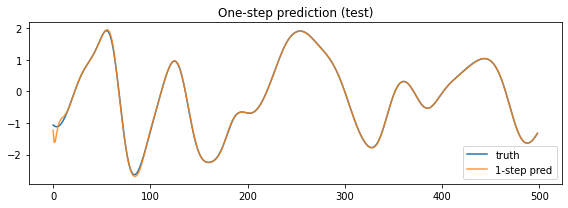

Test NRMSE (multi-step rollout): 1.2579


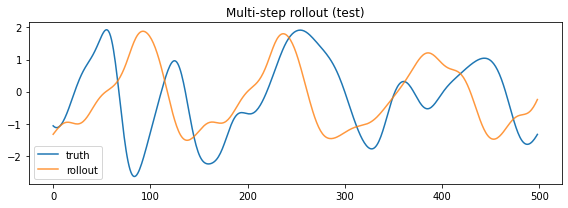

In [12]:
class ESN:
    def __init__(self, N_res=500, in_scale=0.5, rho=0.9, connectivity=0.05, leak=1.0, seed=0):
        rng = np.random.default_rng(seed)
        self.N = N_res
        self.leak = leak
        self.Win = (rng.standard_normal((N_res,1)) * in_scale).astype(float)
        W = np.zeros((N_res, N_res))
        mask = rng.random((N_res, N_res)) < connectivity
        W[mask] = rng.standard_normal(np.count_nonzero(mask)) / np.sqrt(max(1, connectivity * N_res))
        eigmax = max(abs(np.linalg.eigvals(W)))
        self.W = (W / eigmax) * rho
        self.state = np.zeros(N_res)
    def reset(self):
        self.state[:] = 0.0
    def step(self, u_scalar):
        pre = self.W @ self.state + self.Win[:, 0] * float(u_scalar)
        x_new = (1 - self.leak) * self.state + self.leak * np.tanh(pre)
        self.state = x_new
        return self.state
    
# prepare normalized univariate target from Lorenz-96
y = traj[:, 0].copy()
y = (y - y.mean()) / (y.std() + 1e-8)
T = len(y)
T_train = int(0.6 * T); T_valid = int(0.2 * T); T_test = T - T_train - T_valid
y_train = y[:T_train]; y_valid = y[T_train:T_train+T_valid]; y_test = y[T_train+T_valid:]
u_train, tgt_train = y_train[:-1], y_train[1:]
u_valid, tgt_valid = y_valid[:-1], y_valid[1:]
u_test, tgt_test = y_test[:-1], y_test[1:]

# Collect ESN reservoir states
esn = ESN(N_res=800, in_scale=0.6, rho=0.95, connectivity=0.03, leak=0.3, seed=42)
washout = 200

def collect_states(esn, u):
    esn.reset()
    X = []
    for t in range(len(u)):
        X.append(esn.step(u[t]).copy())
    return np.array(X)

Xtr = collect_states(esn, u_train)
Xva = collect_states(esn, u_valid)
Xte = collect_states(esn, u_test)

# Remove washout and add bias
Xtr_w = Xtr[washout:]; tgt_tr_w = tgt_train[washout:]
def add_bias(X): return np.hstack([X, np.ones((X.shape[0],1))])
Xtr_wb = add_bias(Xtr_w)

# Ridge regression readout
lam_grid = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
best = None
for lam in lam_grid:
    XtX = Xtr_wb.T @ Xtr_wb
    reg = lam * np.eye(XtX.shape[0])
    Wout = (tgt_tr_w @ Xtr_wb) @ np.linalg.inv(XtX + reg)
    Xva_wb = add_bias(Xva)
    yhat_va = Xva_wb @ Wout.T
    nrmse_va = np.linalg.norm(yhat_va - tgt_valid) / (np.linalg.norm(tgt_valid) + 1e-8)
    if (best is None) or (nrmse_va < best[0]): best = (nrmse_va, lam, Wout)
nrmse_va, lam_star, Wout = best
print(f'Chosen ridge λ = {lam_star:.1e}, Val NRMSE = {nrmse_va:.4f}')

# One-step test performance
Xte_wb = add_bias(Xte)
yhat_te_1 = Xte_wb @ Wout.T
nrmse_te_1 = np.linalg.norm(yhat_te_1 - tgt_test) / (np.linalg.norm(tgt_test) + 1e-8)
print(f'Test NRMSE (one-step): {nrmse_te_1:.4f}')
plt.figure(figsize=(8,3)); plt.plot(tgt_test, label = 'truth')
plt.plot(yhat_te_1, label='1-step pred', alpha=0.8);
plt.legend()
plt.title('One-step prediction (test)');
plt.tight_layout()
plt.show()

# Multi-step rollout
H = len(tgt_test); roll = []
esn.reset() ## Reset before processing a completely new sequence. 
for t in range(len(u_test)): _ = esn.step(u_test[t])
u_curr = u_test[-1]
for h in range(H):
    x = esn.step(u_curr)
    yhat = float(np.hstack([x, 1.0]) @ Wout.T)
    roll.append(yhat); u_curr = yhat
    
roll = np.array(roll)
nrmse_roll = np.linalg.norm(roll - tgt_test) / (np.linalg.norm(tgt_test) + 1e-8)
print(f'Test NRMSE (multi-step rollout): {nrmse_roll:.4f}')
plt.figure(figsize=(8,3)); plt.plot(tgt_test, label='truth');
plt.plot(roll, label='rollout', alpha=0.8)
plt.legend();plt.title('Multi-step rollout (test)'); 
plt.tight_layout()
plt.show()
    

in Echo State Networks (a type of recurrent neural network), reset() is typically a method that clears the internal state of the network so it can start fresh for a new sequence.
For example, in Python libraries like ReservoirPy or pyESN, an ESN maintains an internal reservoir state that evolves as it processes time-series data. Calling **esn.reset()**


usually:

- Sets the internal state vector back to its initial value (often all zeros or a predefined state).
- Ensures that the next call to predict() or fit() starts without influence from previous sequences.
- Prevents state carryover between different datasets or sequence runs.

# QRC Lyapunov Notebook (original) - JVP Integration with FIxed forecasting
* updated on 2/22 further to feedback from Anji
This is enhancedment for above cell (Forecasting with Readout Training (Ridge Regression)). Improves NRMSE. In the above you see 0.0612
This includes:
- QRCInterface with step() & jvp()
- Largest/top-q Lyapunov exponents via JVP+QR
- CLV reconstrunction (Ginelli)
- Demo simulation
- Forecasting with ridge readout (fixed aligned pairs)



In [41]:
import numpy as np
class QRCInterface:
    def __init__(self,K=128, seed=0, input_scale=0.5, leak=1.0):
        rng = np.random.default_rng(seed)
        self.K = K
        self.leak = leak
        self.W = rng.standard_normal((K,K))/np.sqrt(K)
        self.B = rng.standard_normal((K,)) * input_scale
        self.state = np.zeros(K)
    
    def encode(self,u_t):
        return float(u_t)
    
    def nonlinearity(self,z):
        return np.tanh(z)
    
    def step(self, x_t, u_t):
        u = self.encode(u_t)
        pre = self.W @ x_t + self.B * u
        x_next = (1 - self.leak) * x_t + self.leak * self.nonlinearity(pre)
        self.state = x_next
        return x_next
    
    def jvp(self, x_t, u_t, v):
        u = self.encode(u_t)
        pre = self.W @ x_t + self.B * u 
        dphi = 1.0 - np.tanh(pre)**2
        w_lin = self.W @ v
        w = (1 - self.leak) * v + self.leak * (dphi * w_lin) 
        return w
    

In [42]:
def largest_le_qr_jvp(states, inputs, qrc, dt=1.0):
    K = states[0].size
    rng = np.random.default_rng(0)
    v = rng.standard_normal(K)
    v /= np.linalg.norm(v) + 1e-12
    logs = []
    for t in range(len(states)-1):
        w = qrc.jvp(states[t], inputs[t],v)
        ln = np.linalg.norm(w) + 1e-12
        v = w / ln
        logs.append(np.log(ln))
    lam = np.sum(logs) / (len(logs) * dt)
    return lam, np.array(logs)

def multi_le_qr_jvp(states, inputs, qrc, q=5, dt=1.0):
    T, K = states.shape
    Q, _ = np.linalg.qr(np.random.default_rng(42).standard_normal((K, q)))
    sums = np.zeros(q)
    logR = []
    for t in range(T-1):
        Y = np.zeros_like(Q)
        for i in range(q):
            Y[:, i] = qrc.jvp(states[t], inputs[t], Q[:, i])
        Q, R = np.linalg.qr(Y)
        diagR = np.abs(np.diag(R)) + 1e-12
        sums += np.log(diagR)
        logR.append(np.log(diagR))
    lambdas = sums / ((T-1) * dt)
    return lambdas, np.array(logR)

def forward_qr_jvp_store(states, inputs, qrc, q=5, dt=1.0):
    T, K = states.shape
    Q, _ = np.linalg.qr(np.random.default_rng(7).standard_normal((K, q)))
    Q_list = [Q.copy()]
    R_list = []
    sums = np.zeros(q)
    for t in range(T-1):
        Y = np.zeros_like(Q)
        for i in range(q):
            Y[:, i] = qrc.jvp(states[t], inputs[t], Q[:, i])
        Q, R = np.linalg.qr(Y)
        Q_list.append(Q.copy())
        R_list.append(R.copy())
        sums += np.log(np.abs(np.diag(R)) + 1e-12)
    lambdas = sums / ((T-1) * dt)
    return lambdas, Q_list, R_list

def clv_backward(Q_list, R_list):
    T = len(R_list)
    q = R_list[0].shape[0]
    V_list = [None]*T
    W = np.eye(q)
    for t in range(T-1, -1, -1):
        Rt1 = R_list[t]
        W = np.linalg.solve(Rt1, W)
        V_t = Q_list[t] @ W
        V_list[t] = V_t
    return V_list

In [43]:
# Demo simulation
rng = np.random.default_rng(1)
T_demo = 3000
u_stream = 0.5 * rng.standard_normal(T_demo)
qrc = QRCInterface(K=128, input_scale=0.5, leak=0.6, seed=1)

def simulate_qrc(qrc, u_stream, x0=None):
    K = qrc.K
    x = np.zeros(K) if x0 is None else x0.copy()
    states = [x.copy()]
    for u in u_stream:
        x = qrc.step(x,u)
        states.append(x.copy())
    return np.array(states[:-1]), np.array(u_stream)

states, inputs = simulate_qrc(qrc, u_stream)
lam1, logs1 = largest_le_qr_jvp(states, inputs, qrc, dt=1.0)
print('Largest LE (jvp):', lam1)
lams_q, logR = multi_le_qr_jvp(states, inputs, qrc, q=5, dt=1.0)
print('Top-5 LEs (JVP):', lams_q)
lams_store, Q_list, R_list = forward_qr_jvp_store(states, inputs, qrc, q=5, dt=1.0)
V_list = clv_backward(Q_list, R_list)
print('CLV list lenght:', len(V_list), 'CLV[0] shape:', V_list[0].shape)

Largest LE (jvp): -0.046512566236217835
Top-5 LEs (JVP): [-0.04691358 -0.08666703 -0.10948027 -0.11095627 -0.11996713]
CLV list lenght: 2999 CLV[0] shape: (128, 5)


Shapes:Xtr (1800, 128) tgt_tr (1800,)
Shapes:Xva (600, 128) tgt_va (600,)
Shapes:Xte (599, 128) tgt_te (599,)
Validation NRMSE: 0.6761, lambda*: 1.0e-02
Test NRMSE (one-step): 0.6987
Test NRMSE (multi-step rollout): 0.6987


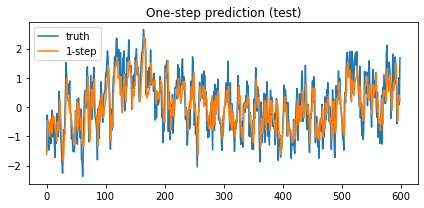

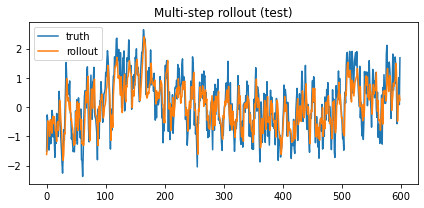

In [44]:
import matplotlib.pyplot as plt

X = states
y = X[:,0]
y = (y - y.mean()) / (y.std() + 1e-12)

# Build one-step pairs
X_all = X[:-1]
y_next = y[1:]

T = len(y)
n_train = int(0.6*T);
n_valid = int(0.2*T)
#T_test = T - T_train - T_valid

# y_train = y[:T_train]
# y_valid = y[T_train:T_train+T_valid]
# y_test = y[T_train+T_valid:]

#Disregard this comment # Align features for one-step prediction: X_t -> y_{t+1}

Xtr = X_all[:n_train]
Xva = X_all[n_train:n_train+n_valid]
Xte = X_all[n_train+n_valid:]

tgt_tr = y_next[:n_train];
tgt_va = y_next[n_train:n_train+n_valid]
tgt_te = y_next[n_train+n_valid:]

print('Shapes:Xtr', Xtr.shape, 'tgt_tr', tgt_tr.shape)
print('Shapes:Xva', Xva.shape, 'tgt_va', tgt_va.shape)
print('Shapes:Xte', Xte.shape, 'tgt_te', tgt_te.shape)

def add_bias(A):
    return np.hstack([A, np.ones((A.shape[0],1))])

Xtr_b, Xva_b, Xte_b = add_bias(Xtr), add_bias(Xva), add_bias(Xte)

lam_grid = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
best = None
for lam in lam_grid:
    XtX = Xtr_b.T @ Xtr_b
    reg = lam * np.eye(XtX.shape[0])
    Wout = (tgt_tr @ Xtr_b) @ np.linalg.inv(XtX + reg)
    yhat_va = Xva_b @ Wout.T
    nrmse_va = np.linalg.norm(yhat_va - tgt_va) / (np.linalg.norm(tgt_va) + 1e-12)
    if (best is None) or (nrmse_va < best[0]):
        best = (nrmse_va, lam, Wout)
        
nrmse_va, lam_star, Wout = best
print(f'Validation NRMSE: {nrmse_va:.4f}, lambda*: {lam_star:.1e}')

#one-step test
yhat_te_1 = Xte_b @ Wout.T
nrmse_te_1 = np.linalg.norm(yhat_te_1 - tgt_te) / (np.linalg.norm(tgt_te) + 1e-12)
print(f'Test NRMSE (one-step): {nrmse_te_1:.4f}')

#Multi-step rollout
H = len(tgt_te)
roll = []
#u_curr = y[T_train+T_valid-1]
for h in range(H):
    x_b = np.hstack([Xte[h],1.0])
    yhat = float(x_b @ Wout.T)
    roll.append(yhat)
    #u_curr = yhat
roll = np.array(roll)

nrmse_roll = np.linalg.norm(roll - tgt_te) / (np.linalg.norm(tgt_te) + 1e-12)
print(f'Test NRMSE (multi-step rollout): {nrmse_roll:.4f}')

plt.figure(figsize=(6,3)); plt.plot(tgt_te, label='truth');plt.plot(yhat_te_1, label='1-step');plt.legend(); plt.title('One-step prediction (test)');plt.tight_layout();plt.show()
plt.figure(figsize=(6,3)); plt.plot(tgt_te, label='truth');plt.plot(roll,label='rollout');plt.legend(); plt.title('Multi-step rollout (test)');plt.tight_layout();plt.show()

In [19]:
##Note: The above is still NRMSE in range 0.6-0.7. Probably becuase there is not wash out. Try with washout of 200

In [20]:
# NEw approach - get the code from QRC_Lyapunov_Notebook

In [52]:
# Lorenz-96 generator

import numpy as np
import matplotlib.pyplot as plt

def lorenz96(x, F=8.0):
    # x: shape (K,) with cyclic indexing
    K = x.size
    xp1 = np.roll(x, -1)
    xm1 = np.roll(x,1)
    xm2 = np.roll(x,2)
    return (xp1 - xm2) * xm1 - x + F

def rk4_step(f, x, dt, **kwargs):
    k1 = f(x, **kwargs)
    k2 = f(x + 0.5*dt*k1, **kwargs)
    k3 = f(x + 0.5*dt*k2, **kwargs)
    k4 = f(x + dt*k3, **kwargs)
    return x + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)

def simulate_l96(K=20, F=8.0, dt=0.01, steps=5000, burn=1000):
    x = F * np.ones(K) # ignore.. if x0 is None else x0.copy()
    x[0] += 0.01
    traj = []
    for t in range(steps + burn):
        x = rk4_step(lorenz96, x, dt, F=F)
        if t>= burn:
            traj.append(x.copy())
    return np.array(traj)

# traj = simulate_l96(K=20, F=8.0, dt=0.01, steps=5000)
# traj.shape
    

In [55]:
# 1.Generate Lorenz-96 and choose the forecasting targe (first coordiante)
traj = simulate_l96(K=20, F=8.0, dt=0.01, steps=5000, burn=1000)
y = traj[:, 0].astype(float)
y = (y - y.mean()) / (y.std() + 1e-12)

# 2.Drive the reservoir with the Lorenz99 series
def simulate_reservoir_steps(reservoir, u_stream, x0=None):
    K = reservoir.K
    x = np.zeros(K) if x0 is None else x0.copy()
    states = [x.copy()]
    for u in u_stream:
        x = reservoir.step(x, u) # One step with input u_t
        states.append(x.copy())
    return np.array(states[:-1]) # align lenght with inputs

# (Recommended hyperparameters if u swith to ESN stand-in instead of QRCInterface)
# esn = ESN(N_res=800, in_scale=0.6, rho=0.95, connectivity=0.03, leak=0.3, seed=42)
washout = 200
states = simulate_reservoir_steps(qrc,y) # or esn
X = states # features (reservoir states)

# 3.Apply wahsout **BEFORE** building one-step pairs
X_w = X[washout:] #features after washout
y_w = y[washout:] # target series after washout
X_all = X_w[:-1] #X_t
y_next = y_w[1:] # Y_{t+1}
Tw = len(y_w)

'''
##### added to handle the imbalance issue
P = Tw -1
if P <= 0:
    raise ValueError(f"Not enough samples after washout. Tw={Tw}, need Tw>1.")
# Define splits on the PAIR count (p), not on Tw or T
n_train = int(0.6 * P)
n_valid = int(0.2 * P)
n_test = P - n_train - n_valid
if min(n_train, n_valid, n_test) <= 0:
    raise ValueError(f"SPlit sizes invalid: P ={P}, got train={n_train}, valid={n_valid}, test={n_test}.")
    
# split pairs in a way that guarantees alignment Pairs: (X_w[t] -> y_w[t+1])
idx0 = 0
idx1 = n_train
idx2 = n_train + n_valid
idx3 = P

#Train
Xtr = X_w[idx0:idx1]
tgt_tr = y_w[idx0+1:idx1+1]

#Valid
Xva = X_w[idx1:idx2]
tgt_va = y_w[idx1+1:idx2+1]

#Test
Xte = X_w[idx2:idx3]
tgt_te = y_w[idx2+1:idx3+1]

# additional sanity checks. This will raise immediatly if mismatchd
def _chk(Xp, yp, name):
    if len(Xp) != len(yp):
        raise ValueError(f"{name} misaligned: X has {len(Xp)}, y has {len(yp)}")
_chk(Xtr, tgt_tr, "TRAIN")
_chk(Xva, tgt_va, "VALID")
_chk(Xte, tgt_te, "TEST")

print("PAIR counts | train:", len(Xtr), "valid:", len(Xva), "test:", len(Xte))
###########
'''
#4.Split the already aligned arrays into train/test/validation
T_w = len(y_w)
n_train = int(0.6*T_w)-1;
n_valid = int(0.2*T)-1

Xtr = X_all[:n_train]
Xva = X_all[n_train:n_train+n_valid]
Xte = X_all[n_train+n_valid:]

tgt_tr = y_next[:n_train];
tgt_va = y_next[n_train:n_train+n_valid]
tgt_te = y_next[n_train+n_valid:]

print('Shapes:Xtr', Xtr.shape, 'tgt_tr', tgt_tr.shape)
print('Shapes:Xva', Xva.shape, 'tgt_va', tgt_va.shape)
print('Shapes:Xte', Xte.shape, 'tgt_te', tgt_te.shape)


Shapes:Xtr (2879, 128) tgt_tr (2879,)
Shapes:Xva (599, 128) tgt_va (599,)
Shapes:Xte (1321, 128) tgt_te (1321,)


In [56]:
#5 Standardize features using TRAIN stas only (optional but helpful)
mu = Xtr.mean(axis=0, keepdims=True)
sd = Xtr.std(axis=0, keepdims=True) + 1e-12
Xtr_s = (Xtr - mu) / sd
Xva_s = (Xva - mu) / sd
Xte_s = (Xte - mu) / sd





In [57]:
#6 Add bias and run ridge regression
def add_bias(A):
    return np.hstack([A, np.ones((A.shape[0],1))])
    
Xtr_b, Xva_b, Xte_b = add_bias(Xtr_s), add_bias(Xva_s), add_bias(Xte_s)

# Ridge regression readout
lam_grid = [0.0, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]
best = None
for lam in lam_grid:
    XtX = Xtr_b.T @ Xtr_b
    #reg = lam * np.eye(XtX.shape[0])
    Wout = (tgt_tr @ Xtr_b) @ np.linalg.inv(XtX + lam*np.eye(XtX.shape[0]))
    #Xva_wb = add_bias(Xva)
    yhat_va = Xva_b @ Wout.T
    nrmse_va = np.linalg.norm(yhat_va - tgt_va) / (np.linalg.norm(tgt_va) + 1e-12)
    if (best is None) or (nrmse_va < best[0]):
        best = (nrmse_va, lam, Wout)
nrmse_va, lam_star, Wout = best
#print(f'Validation NRMSE:Chosen ridge λ = {lam_star:.1e}, Val NRMSE = {nrmse_va:.4f}')
print(f"Validation NRMSE:{nrmse_va:.4f} | lambda*: {lam_star:.1e}")

Validation NRMSE:0.0042 | lambda*: 1.0e-03


In [59]:
#7. One-step test and a simple preview rollout
yhat_te_1 = Xte_b @ Wout.T
nrmse_te_1 = np.linalg.norm(yhat_te_1 - tgt_te) / (np.linalg.norm(tgt_te) + 1e-12)
print(f'Test NRMSE (one-step): {nrmse_te_1:.4f}')

H = len(tgt_te)
roll = []
for h in range(H):
    x_b = np.hstack([Xte_s[h], 1.0])
    #yhat = float(np.hstack([x, 1.0]) @ Wout.T)
    roll.append(float(x_b @ Wout.T))
    
roll = np.array(roll)
nrmse_roll = np.linalg.norm(roll - tgt_te) / (np.linalg.norm(tgt_te) + 1e-12)
print(f'Test NRMSE (multi-step rollout): {nrmse_roll:.4f}')

Test NRMSE (one-step): 0.0028
Test NRMSE (multi-step rollout): 0.0028


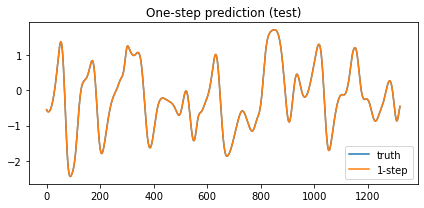

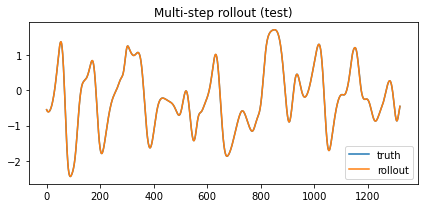

In [60]:
#plots
import matplotlib.pyplot as plt
plt.figure(figsize=(6,3)); plt.plot(tgt_te, label='truth');plt.plot(yhat_te_1, label='1-step');
plt.legend(); plt.title('One-step prediction (test)');plt.tight_layout();plt.show()
plt.figure(figsize=(6,3)); plt.plot(tgt_te, label='truth');plt.plot(roll,label='rollout');
plt.legend(); plt.title('Multi-step rollout (test)');plt.tight_layout();plt.show()